<a href="https://colab.research.google.com/github/jomanakhatib/Projects-/blob/main/Ohio_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# =========================
# 1. Imports
# =========================
import os
import random
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [39]:
import os

# =========================
# 2. Paths
# =========================
OHIO_TRAIN_PATH = "/content/Ohio Dataset/2020/train"
OHIO_TEST_PATH = "/content/Ohio Dataset/2020/test"

print("Train files:", os.listdir(OHIO_TRAIN_PATH))
print("Test files:", os.listdir(OHIO_TEST_PATH))

OHIO_TRAIN_PATH = "/content/Ohio Dataset/2018/train"
OHIO_TEST_PATH = "/content/Ohio Dataset/2018/test"

print("Train files:", os.listdir(OHIO_TRAIN_PATH))
print("Test files:", os.listdir(OHIO_TEST_PATH))

Train files: ['596-ws-training.xml', '544-ws-training.xml', '567-ws-training.xml', '540-ws-training.xml', '552-ws-training.xml', '584-ws-training.xml']
Test files: ['584-ws-testing.xml', '552-ws-testing.xml', '540-ws-testing.xml', '544-ws-testing.xml', '596-ws-testing.xml', '567-ws-testing.xml']
Train files: ['575-ws-training.xml', '563-ws-training.xml', '570-ws-training.xml', '591-ws-training.xml', '588-ws-training.xml', '559-ws-training.xml']
Test files: ['559-ws-testing.xml', '591-ws-testing.xml', '588-ws-testing.xml', '575-ws-testing.xml', '563-ws-testing.xml', '570-ws-testing.xml']


In [40]:
# =========================
# 3. Settings
# =========================
INPUT_STEPS = 36     # 180 minutes
OUTPUT_STEPS = 12    # 60 minutes

FEATURE_COLS = [
    "glucose",
    "glucose_lag_30",
    "glucose_roc_15",
    "glucose_roll_std_30",
    "hour_sin",
    "hour_cos"
]

In [41]:
# =========================
# 4. Load Ohio XML
# =========================
def load_ohio_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    patient_id = root.attrib.get("id", os.path.basename(file_path))
    glucose_node = root.find("glucose_level")

    if glucose_node is None:
        return pd.DataFrame()

    rows = []
    for event in glucose_node.findall("event"):
        ts = event.attrib.get("ts")
        value = event.attrib.get("value")

        if ts is not None and value is not None:
            rows.append({
                "patient_id": patient_id,
                "timestamp": ts,
                "glucose": float(value)
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        format="%d-%m-%Y %H:%M:%S",
        errors="coerce"
    )

    df = df.dropna(subset=["timestamp", "glucose"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    return df

In [42]:
# =========================
# 5. Feature Engineering
# =========================
def add_features(df):
    df = df.copy()

    df["glucose_lag_30"] = df["glucose"].shift(6)
    df["glucose_roc_15"] = df["glucose"].diff(3)
    df["glucose_roll_std_30"] = df["glucose"].rolling(window=6).std()

    df["hour"] = df["timestamp"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df = df.drop(columns=["hour"])
    df = df.dropna().reset_index(drop=True)

    return df

In [43]:
# =========================
# 6. Load Train/Test Folders
# =========================
def load_folder(folder_path):
    patient_data = {}

    for file_name in sorted(os.listdir(folder_path)):
        if file_name.endswith(".xml"):
            file_path = os.path.join(folder_path, file_name)

            df = load_ohio_xml(file_path)

            if df.empty:
                continue

            df = add_features(df)

            patient_id = file_name.split("-")[0]
            patient_data[patient_id] = df

    return patient_data


train_data = load_folder(OHIO_TRAIN_PATH)
test_data = load_folder(OHIO_TEST_PATH)

print("Train patients:", list(train_data.keys()))
print("Test patients:", list(test_data.keys()))

Train patients: ['559', '563', '570', '575', '588', '591']
Test patients: ['559', '563', '570', '575', '588', '591']


In [44]:
# =========================
# 7. Sequence Builder
# =========================
def build_sequences(df, feature_cols):
    X, y = [], []

    values = df[feature_cols].values
    target = df["glucose"].values

    for i in range(len(df) - INPUT_STEPS - OUTPUT_STEPS):
        X.append(values[i:i + INPUT_STEPS])
        y.append(target[i + INPUT_STEPS:i + INPUT_STEPS + OUTPUT_STEPS])

    return np.array(X), np.array(y)

In [55]:
# =========================
# 8. Prepare Data
# =========================
def prepare_data(patient_dict):
    X_all, y_all, patient_ids = [], [], []

    for patient_id, df in patient_dict.items():
        if len(df) < INPUT_STEPS + OUTPUT_STEPS:
            print(f"Skipping patient {patient_id}: not enough data")
            continue

        scaler = MinMaxScaler()

        df_scaled = df.copy()
        df_scaled[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])

        X, y = build_sequences(df_scaled, FEATURE_COLS)

        if len(X) == 0:
            print(f"Skipping patient {patient_id}: no sequences created")
            continue

        X_all.append(X)
        y_all.append(y)
        patient_ids.extend([patient_id] * len(X))

        print(f"Patient {patient_id}: X={X.shape}, y={y.shape}")

    return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0), np.array(patient_ids)


X_train, y_train, train_patient_ids = prepare_data(train_data)
X_test, y_test, test_patient_ids = prepare_data(test_data)

print("Final X_train:", X_train.shape)
print("Final y_train:", y_train.shape)
print("Final X_test:", X_test.shape)
print("Final y_test:", y_test.shape)

Patient 559: X=(10742, 36, 6), y=(10742, 12)
Patient 563: X=(12070, 36, 6), y=(12070, 12)
Patient 570: X=(10928, 36, 6), y=(10928, 12)
Patient 575: X=(11812, 36, 6), y=(11812, 12)
Patient 588: X=(12586, 36, 6), y=(12586, 12)
Patient 591: X=(10793, 36, 6), y=(10793, 12)
Patient 559: X=(2460, 36, 6), y=(2460, 12)
Patient 563: X=(2516, 36, 6), y=(2516, 12)
Patient 570: X=(2691, 36, 6), y=(2691, 12)
Patient 575: X=(2536, 36, 6), y=(2536, 12)
Patient 588: X=(2737, 36, 6), y=(2737, 12)
Patient 591: X=(2706, 36, 6), y=(2706, 12)
Final X_train: (68931, 36, 6)
Final y_train: (68931, 12)
Final X_test: (15646, 36, 6)
Final y_test: (15646, 12)


In [56]:
# =========================
# 9. Build Improved LSTM Model
# =========================
model = Sequential([
    LSTM(50, activation="tanh", input_shape=(INPUT_STEPS, len(FEATURE_COLS))),
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(OUTPUT_STEPS)
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,428 (52.45 KB)

 Trainable params: 13,428 (52.45 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# =========================
# 10. Train Model
# =========================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# Prediction on test set
# =========================
pred = model.predict(X_test)

print("Prediction shape:", pred.shape)

test_rmse = rmse(y_test, pred)
test_zone_a = clarke_zone_a_percentage(y_test, pred)

print("RMSE:", test_rmse)
print("Zone A:", test_zone_a)

Epoch 1/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - loss: 0.0113 - val_loss: 0.0077
Epoch 2/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - loss: 0.0062 - val_loss: 0.0071
Epoch 3/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0057 - val_loss: 0.0069
Epoch 4/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0054 - val_loss: 0.0067
Epoch 5/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - loss: 0.0053 - val_loss: 0.0067
Epoch 6/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0052 - val_loss: 0.0066
Epoch 7/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0051 - val_loss: 0.0066
Epoch 8/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - loss: 0.0051 - val_loss: 0.0065
Epoch 9/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - loss: 0.0050 - val_loss: 0.0065
Epoch 10/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 0.0050 - val_loss: 0.0065
Epoch 11/50
1831/1831 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 0.0050 - val_loss: 0.0065
Epoch 12

In [58]:
# =========================
# 11. Evaluation Metrics
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))


def clarke_zone_a_percentage(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    zone_a = (
        (np.abs(y_pred - y_true) <= 0.20 * y_true) |
        ((y_true < 70) & (y_pred < 70))
    )

    return np.mean(zone_a) * 100

In [59]:
# =========================
# 12. Evaluate
# =========================
pred = model.predict(X_test)

test_rmse = rmse(y_test, pred)
test_zone_a = clarke_zone_a_percentage(y_test, pred)

print("Ohio Dataset External Validation Results")
print("RMSE:", round(test_rmse, 2), "mg/dL")
print("Zone A:", round(test_zone_a, 2), "%")

489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Ohio Dataset External Validation Results
RMSE: 0.08 mg/dL
Zone A: 100.0 %


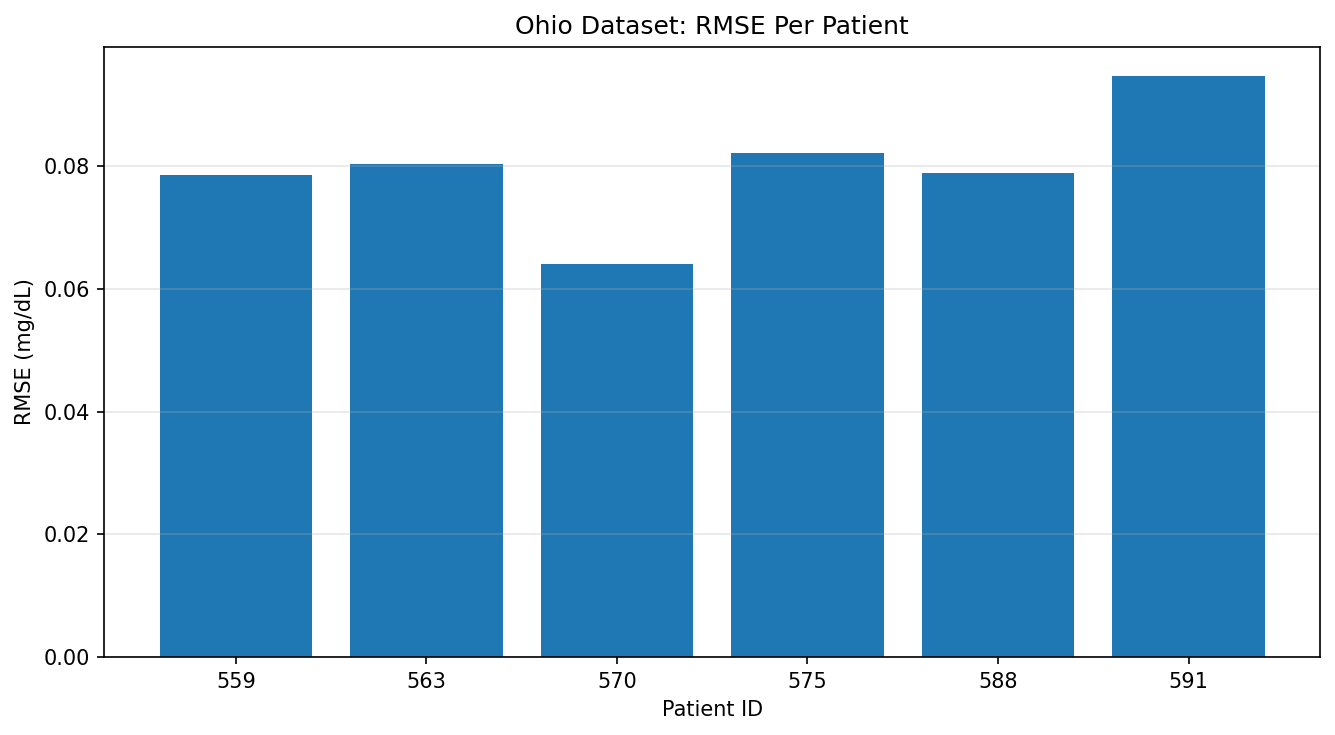

In [61]:
unique_patients = np.unique(test_patient_ids)
patient_rmses = []

for patient_id in unique_patients:
    patient_indices = np.where(test_patient_ids == patient_id)[0]
    patient_y_test = y_test[patient_indices]
    patient_pred = pred[patient_indices]

    current_rmse = rmse(patient_y_test, patient_pred)
    patient_rmses.append({"Patient": patient_id, "RMSE": current_rmse})

patient_df = pd.DataFrame(patient_rmses)

plt.figure(figsize=(9, 5), dpi=150)

plt.bar(patient_df["Patient"], patient_df["RMSE"])
plt.title("Ohio Dataset: RMSE Per Patient")
plt.xlabel("Patient ID")
plt.ylabel("RMSE (mg/dL)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ohio_fig_o1_rmse_per_patient.png", dpi=300, bbox_inches="tight")
plt.show()

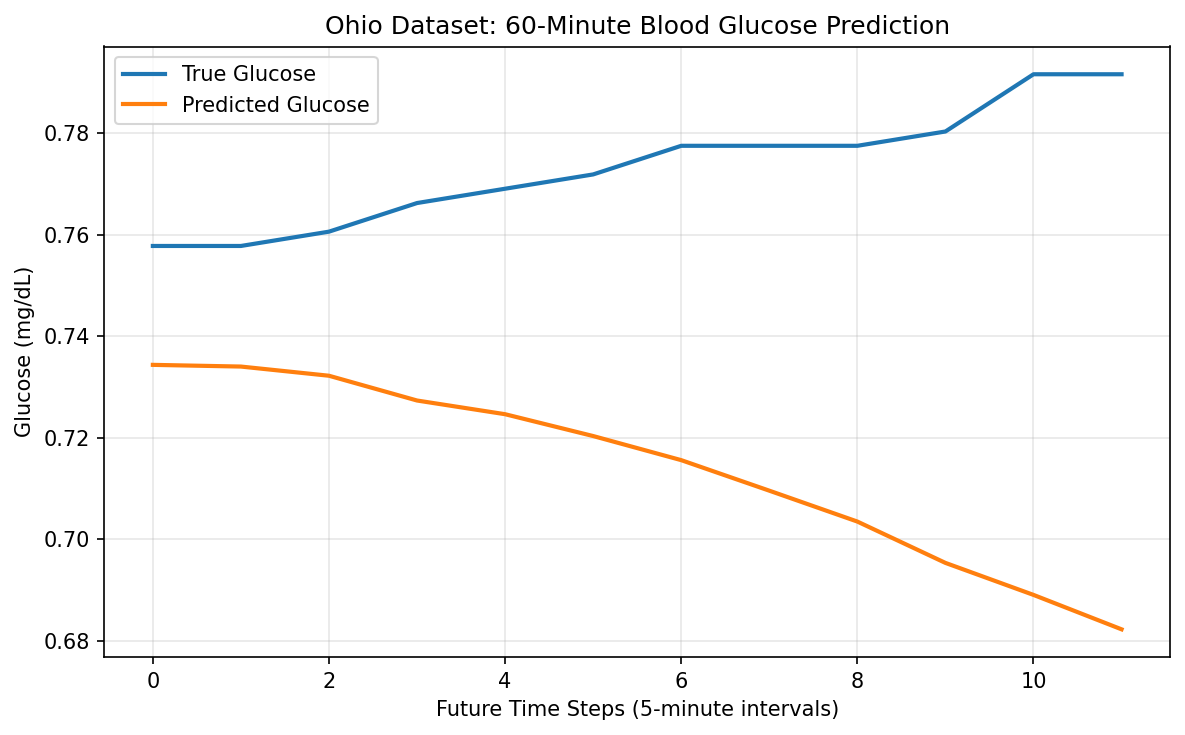

In [67]:
# =========================
# 14. Prediction Example Graph
# =========================
idx = 0

plt.figure(figsize=(8, 5), dpi=150)

plt.plot(y_test[idx], label="True Glucose", linewidth=2)
plt.plot(pred[idx], label="Predicted Glucose", linewidth=2)

plt.title("Ohio Dataset: 60-Minute Blood Glucose Prediction")
plt.xlabel("Future Time Steps (5-minute intervals)")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("ohio_prediction_example.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_41194/3461872777.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(patient_df["RMSE"], labels=["Ohio LSTM"])


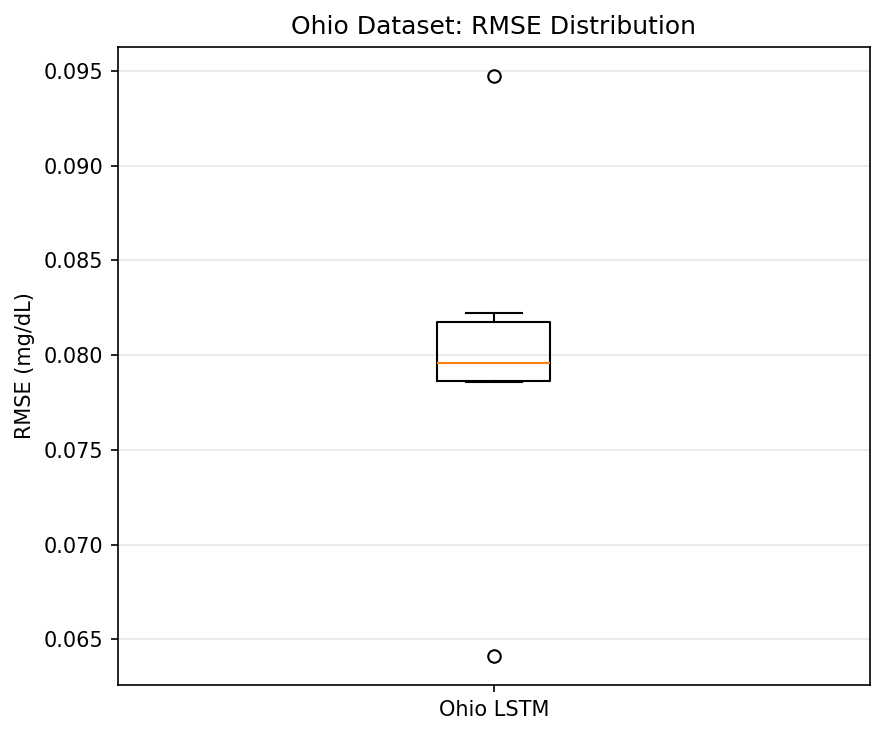

In [70]:
plt.figure(figsize=(6, 5), dpi=150)

plt.boxplot(patient_df["RMSE"], labels=["Ohio LSTM"])
plt.title("Ohio Dataset: RMSE Distribution")
plt.ylabel("RMSE (mg/dL)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ohio_fig_o2_rmse_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

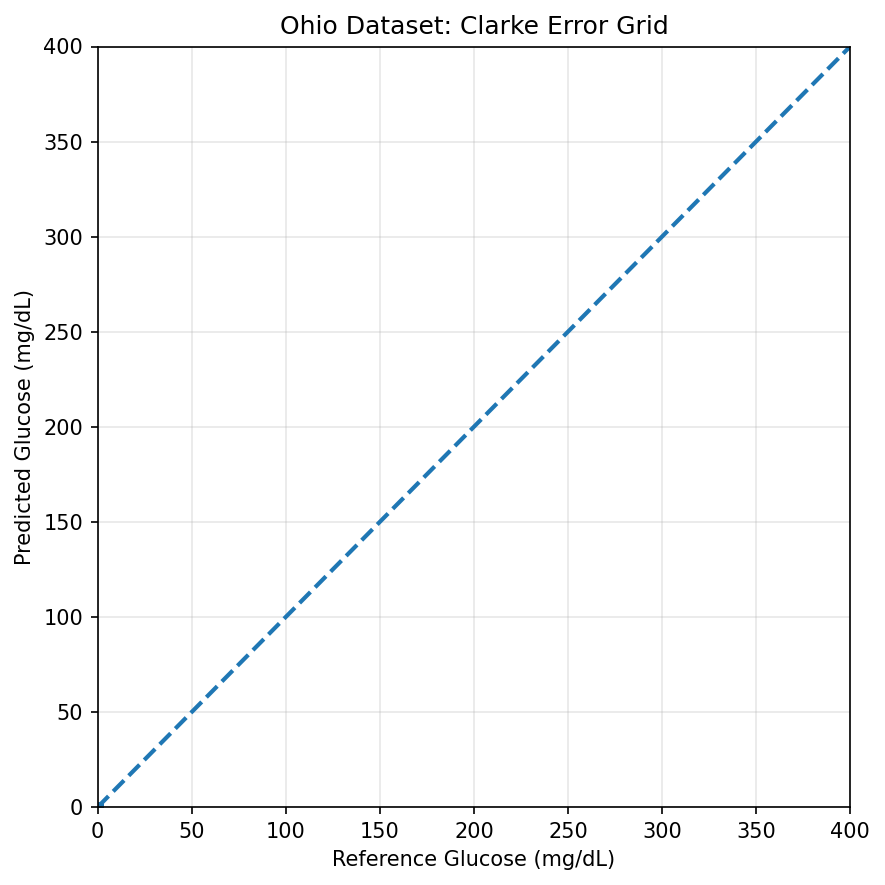

In [75]:
def plot_clarke_simple(y_true, y_pred, save_name="ohio_fig_o3_clarke_grid.png"):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    plt.figure(figsize=(6, 6), dpi=150)
    plt.scatter(y_true, y_pred, s=5, alpha=0.4)

    plt.plot([0, 400], [0, 400], linestyle="--", linewidth=2)

    plt.title("Ohio Dataset: Clarke Error Grid")
    plt.xlabel("Reference Glucose (mg/dL)")
    plt.ylabel("Predicted Glucose (mg/dL)")
    plt.xlim(0, 400)
    plt.ylim(0, 400)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


plot_clarke_simple(y_test, pred)

In [77]:
avg_rmse = patient_df["RMSE"].mean()
avg_zone_a = patient_df_zone_a["Zone A"].mean()

summary_df = pd.DataFrame({
    "Metric": ["Average RMSE", "Average Zone A"],
    "Value": [avg_rmse, avg_zone_a]
})

print(summary_df)
summary_df.to_csv("ohio_summary_results.csv", index=False)

           Metric       Value
0    Average RMSE    0.079807
1  Average Zone A  100.000000


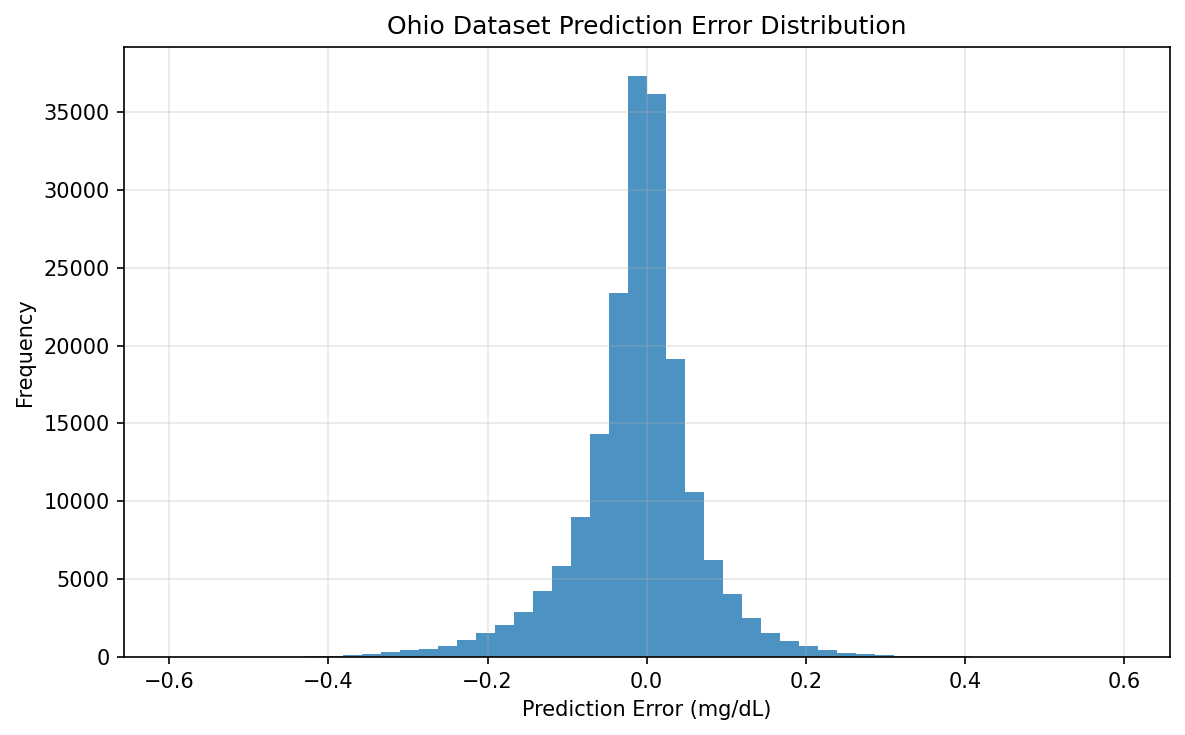

In [68]:
# =========================
# 15. Error Distribution Graph
# =========================
errors = pred.flatten() - y_test.flatten()

plt.figure(figsize=(8, 5), dpi=150)

plt.hist(errors, bins=50, alpha=0.8)

plt.title("Ohio Dataset Prediction Error Distribution")
plt.xlabel("Prediction Error (mg/dL)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("ohio_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [69]:
# =========================
# 16. Save Results
# =========================
results = pd.DataFrame({
    "Metric": ["RMSE", "Zone A Accuracy"],
    "Value": [round(test_rmse, 2), round(test_zone_a, 2)]
})

results.to_csv("ohio_external_validation_results.csv", index=False)

print(results)
print("Saved files:")
print("- ohio_training_validation_loss.png")
print("- ohio_prediction_example.png")
print("- ohio_error_distribution.png")
print("- ohio_external_validation_results.csv")

            Metric   Value
0             RMSE    0.08
1  Zone A Accuracy  100.00
Saved files:
- ohio_training_validation_loss.png
- ohio_prediction_example.png
- ohio_error_distribution.png
- ohio_external_validation_results.csv


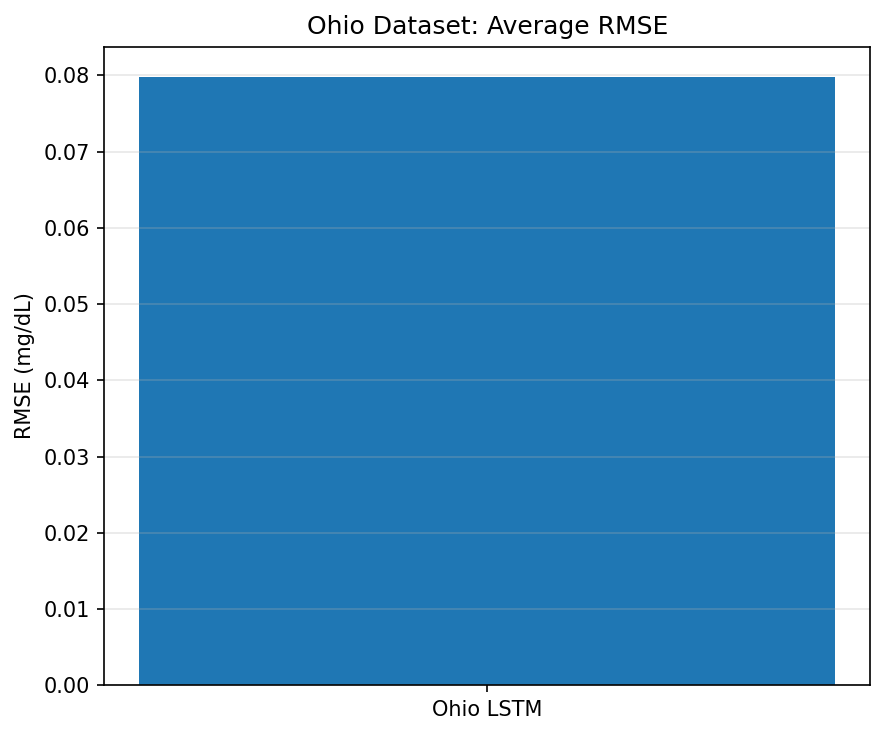

In [78]:
plt.figure(figsize=(6, 5), dpi=150)

plt.bar(["Ohio LSTM"], [avg_rmse])
plt.title("Ohio Dataset: Average RMSE")
plt.ylabel("RMSE (mg/dL)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("ohio_fig_o5_average_rmse.png", dpi=300, bbox_inches="tight")
plt.show()